In [1]:
import pandas as pd
import numpy as np
from SynOmics.processing.preprocessing import DataProcessor
from SynOmics.processing.metadata import MetaData

clinical_data = pd.read_csv("../../Data/Data_Braun/metadata_Braun.csv").drop(columns=["SUBJID"])


omics_data = pd.read_csv("../../Data/Data_Braun/RnaExpression.csv")

ModuleNotFoundError: No module named 'sklearn'

In [2]:
# Transpose the data while keeping gene names as columns
omics_data_t = omics_data.set_index("gene_id").T.reset_index()

# Rename the first column to 'Sample'
omics_data_t = omics_data_t.rename(columns={"index": "Sample"})

# Remove any column name above the header row (optional cleanup)
omics_data_t.columns.name = None

omics_data_t.head()


,Sample,ENSG00000223972.5,ENSG00000227232.5,ENSG00000284332.1,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.7,ENSG00000238009.6,ENSG00000239945.1,...,ENSG00000198899.2,ENSG00000198938.2,ENSG00000198840.2,ENSG00000212907.2,ENSG00000198886.2,ENSG00000210176.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2
0,EA595454,26.54007,33.80347,28.53545,20.97285,20.96062,20.98701,20.92249,25.85548,22.85383,...,34.14651,33.56792,33.19294,32.56782,34.09923,21.10332,33.06912,33.38153,21.21964,32.54588
1,EA595455,26.12424,34.59298,20.59122,20.97285,20.96062,20.98701,20.92249,25.81788,23.22073,...,35.02872,33.97995,35.06923,34.55513,35.18509,21.10332,34.10239,34.41628,21.21964,33.72339
2,EA595473,21.95920,34.42450,27.72119,20.97285,20.96062,20.98701,20.92249,25.79308,20.80101,...,32.15812,32.02668,31.96678,30.42106,32.97165,21.10332,32.30418,32.09198,21.21964,31.66722
3,EA595500,28.63682,34.64308,20.59122,20.97285,20.96062,20.98701,20.92249,27.51352,22.67477,...,35.78078,35.15484,36.14855,35.08009,35.96388,21.10332,35.00759,35.55580,21.21964,34.64529
4,EA595522,23.43039,33.72739,20.59122,20.97285,20.96062,20.98701,20.92249,25.79623,20.80101,...,33.50435,33.35543,33.84238,32.74205,33.87509,21.10332,32.84753,32.33502,21.21964,32.88763


In [22]:
selected_cols = ['Cohort', 'Arm',"RNA_ID",'Sex', 'Age', 'MSKCC','Sarc', 'Rhab','Number_of_Prior_Therapies',
                 'Tumor_Sample_Primary_or_Metastasis','Tumor_Shrinkage', 'ORR', 'Benefit', 'ExtremeResponder', 'PFS', 'PFS_CNSR', 'OS', 'OS_CNSR',
                 'ImmunoPhenotype','Amplification_5p15.33', 'Amplification_5q31.3', 'Amplification_5q35.3',
                 'Deletion_3p21.1','Deletion_6p22.2', 'Deletion_6p21.32', 'Deletion_6p12.1',
                 'Deletion_9p21.3', 'Deletion_9q34.3', 'Deletion_10q23.31', 'Deletion_10q26.3',
                 'Deletion_14q32.33', 'ARID1A', 'ATM', 'BAP1', 'COL9A3', 'KDM5C', 'MTOR', 'NF2', 'PBRM1', 'PCK1', 'PIK3CA', 'PTEN', 'S100B', 'SETD2', 
                 'SMARCA4', 'TCEB1', 'TP53', 'TRMT2B', 'TSC1', 'USP32', 'VHL', 'WNT8A', 'ZNF800'
]
clinical_data = clinical_data[selected_cols]

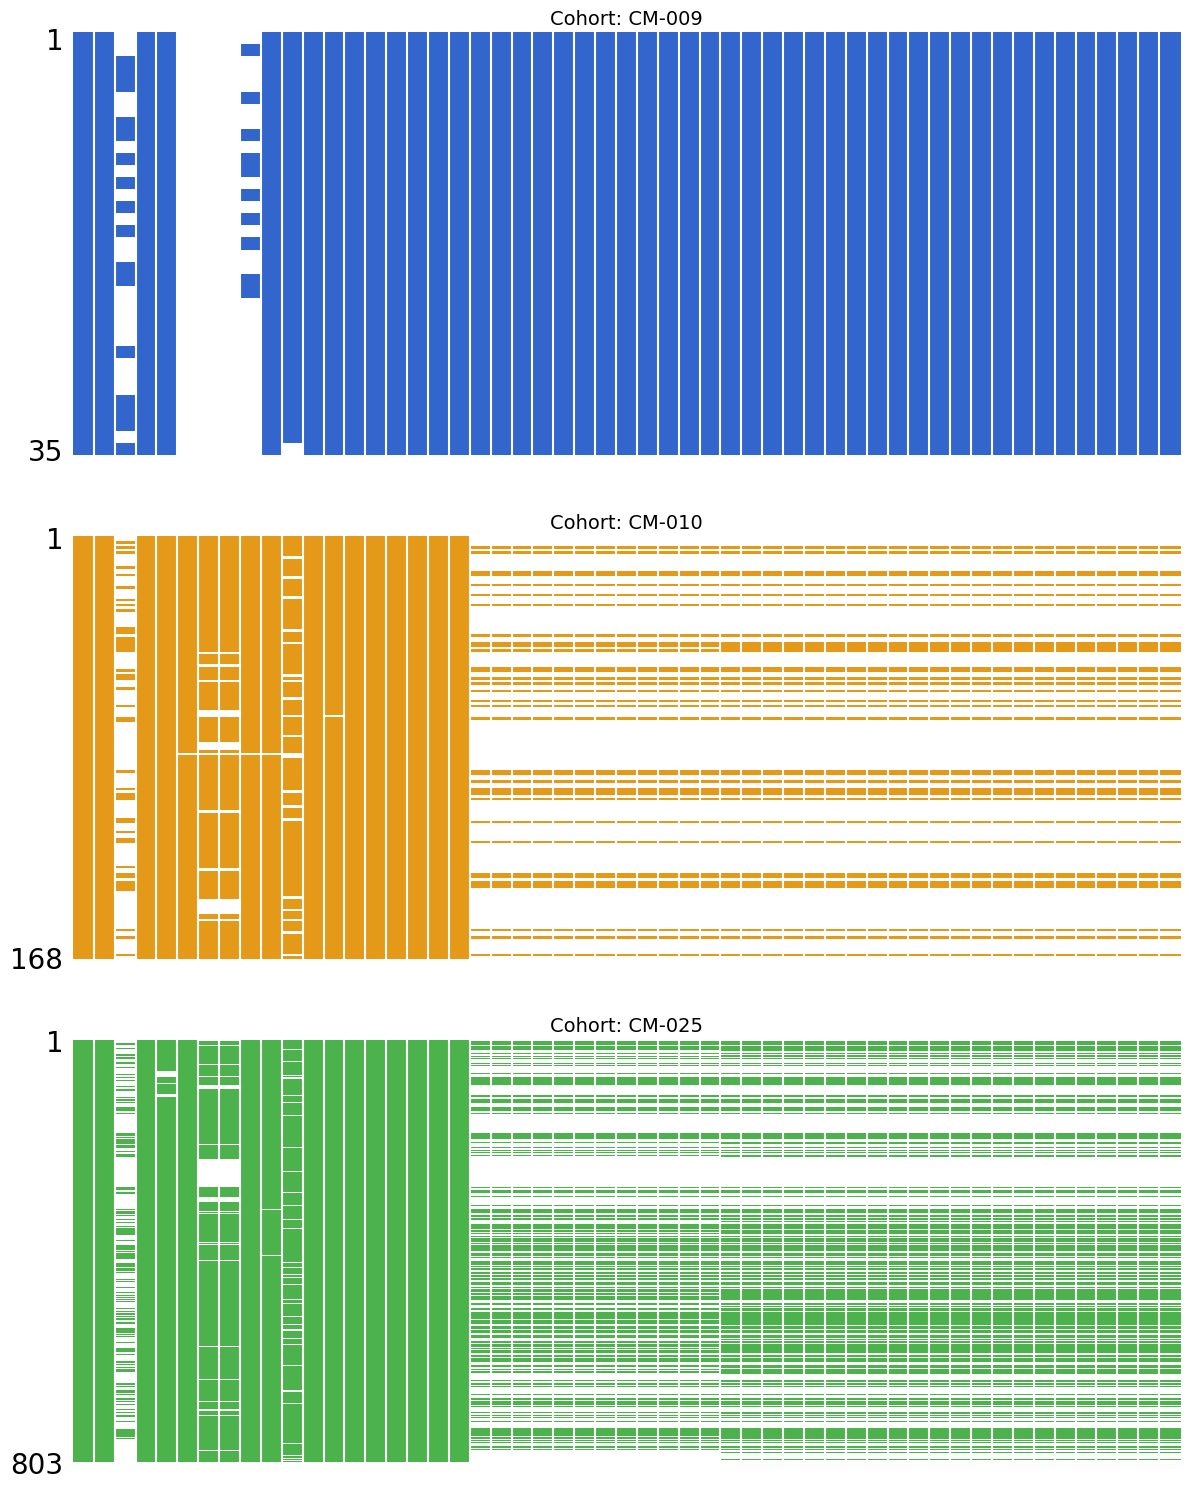

In [23]:
import missingno as msno
import matplotlib.pyplot as plt
# Define cohorts and colors
cohorts = ["CM-009", "CM-010", "CM-025"]
colors = [(0.2, 0.4, 0.8), (0.9, 0.6, 0.1), (0.3, 0.7, 0.3)]  # blue, orange, green

# Create vertically stacked subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=False)  # sharex=True hides repeated x-axis labels

# Plot missingness per cohort
for i, (cohort, color) in enumerate(zip(cohorts, colors)):
    subset = clinical_data[clinical_data["Cohort"] == cohort]
    msno.matrix(subset, ax=axes[i], color=color)
    axes[i].set_title(f"Cohort: {cohort}", fontsize=14)
    
    # Hide x-axis labels for all but the last plot
    if i < len(cohorts) - 1:
        axes[i].set_xlabel("")
        axes[i].set_xticklabels([])

# Adjust layout and show
plt.tight_layout(h_pad=3)
plt.show()

In [24]:
cm09_corhort = clinical_data[clinical_data["Cohort"]=="CM-009"]
cm25_cohort = clinical_data[clinical_data["Cohort"]=="CM-025"]
cm10_cohort = clinical_data[clinical_data["Cohort"]=="CM-010"]
#CM-009
fill_values = {
    "Sarc": "NO_IF",        
    "Rhab": "NO_IF",
    "MSKCC":"NO_IF"
}

cm09_corhort = cm09_corhort.fillna(value=fill_values)

genomic_mut = ['Amplification_5p15.33', 'Amplification_5q31.3', 'Amplification_5q35.3',
                 'Deletion_3p21.1','Deletion_6p22.2', 'Deletion_6p21.32', 'Deletion_6p12.1',
                 'Deletion_9p21.3', 'Deletion_9q34.3', 'Deletion_10q23.31', 'Deletion_10q26.3',
                 'Deletion_14q32.33', 'ARID1A', 'ATM', 'BAP1', 'COL9A3', 'KDM5C', 'MTOR', 'NF2', 'PBRM1', 'PCK1', 'PIK3CA', 'PTEN', 'S100B', 'SETD2', 
                 'SMARCA4', 'TCEB1', 'TP53', 'TRMT2B', 'TSC1', 'USP32', 'VHL', 'WNT8A', 'ZNF800']
fill_value_genomic = "NO_IF"

# Build a dictionary for the columns
fill_dict_genomics = {col: fill_value_genomic for col in genomic_mut}
cm25_cohort = cm25_cohort.fillna(value=fill_dict_genomics)
cm10_cohort = cm10_cohort.fillna(value=fill_dict_genomics)


clinical_data_1 = pd.concat([cm10_cohort,cm25_cohort,cm09_corhort], axis = 0)

cols_to_replace = ["Sarc", "Rhab"]
clinical_data_1[cols_to_replace] = clinical_data_1[cols_to_replace].replace({0: "No", 1: "Yes"})

clinical_data_1['Sex'] = (
    clinical_data_1['Sex']
    .str.strip()             
    .str.upper()          
    .map({'M': 'Male', 'F': 'Female', 'MALE': 'Male', 'FEMALE': 'Female'})
)

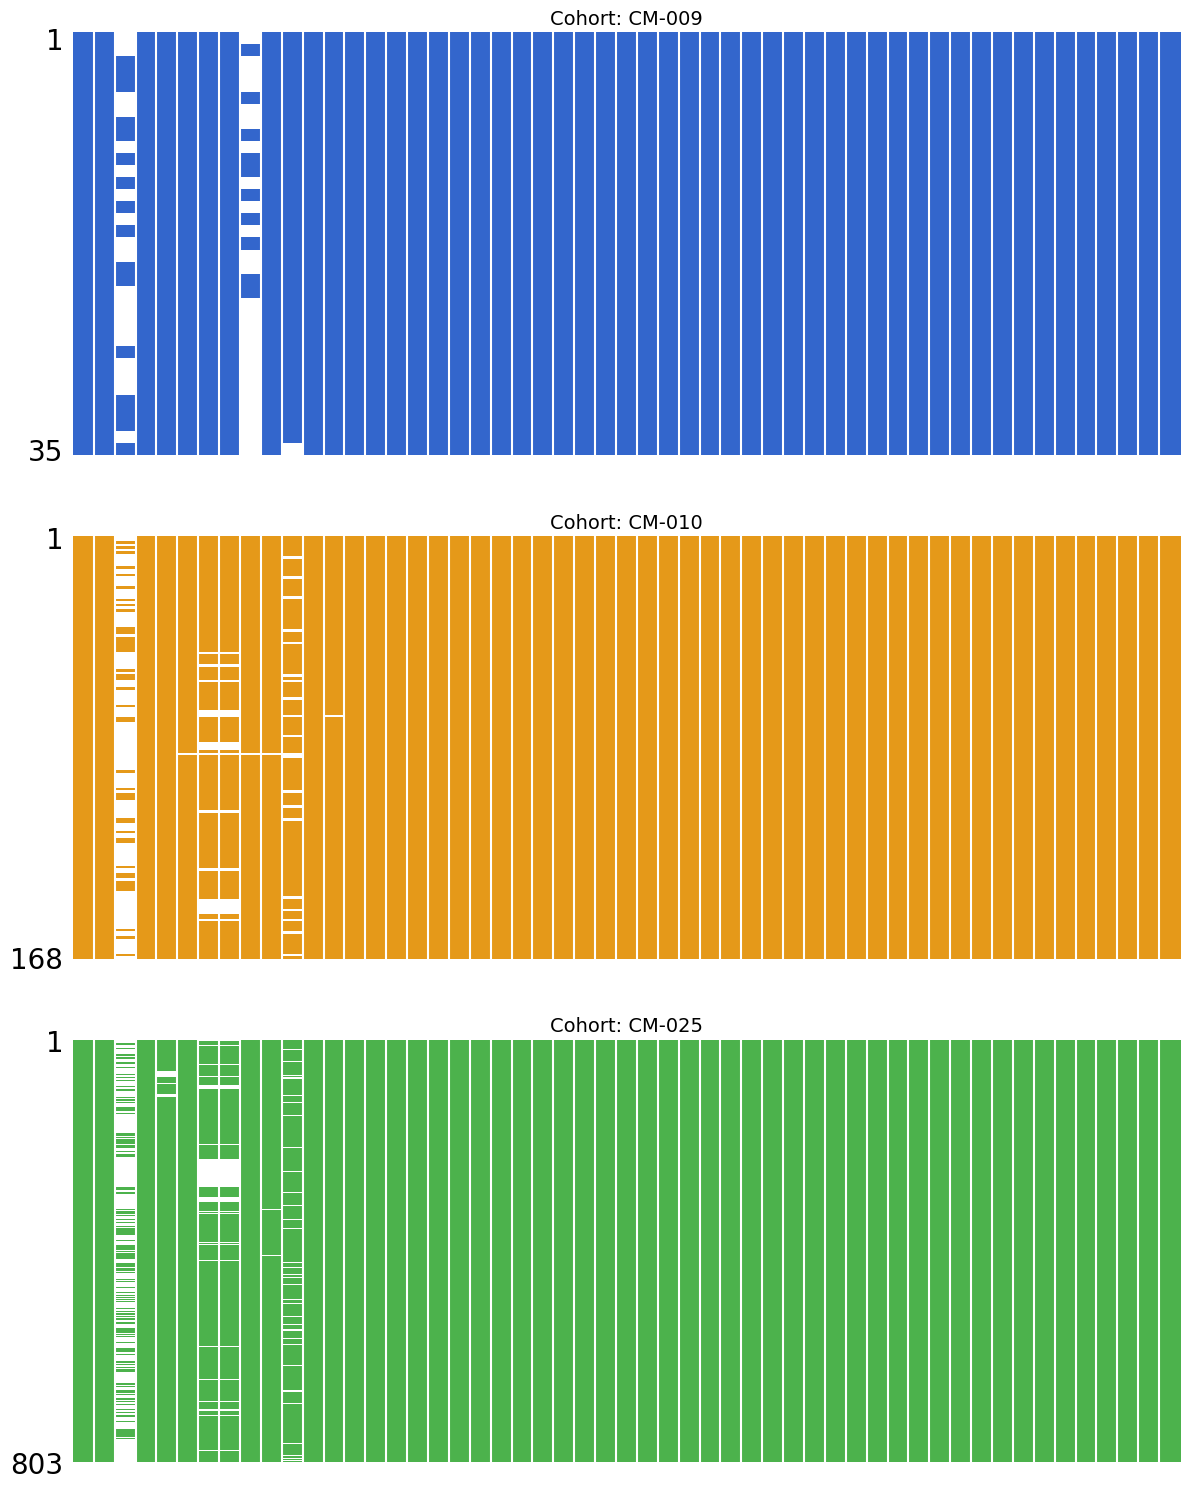

In [27]:
import missingno as msno
import matplotlib.pyplot as plt
# Define cohorts and colors
cohorts = ["CM-009", "CM-010", "CM-025"]
colors = [(0.2, 0.4, 0.8), (0.9, 0.6, 0.1), (0.3, 0.7, 0.3)]  # blue, orange, green

# Create vertically stacked subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=False)  # sharex=True hides repeated x-axis labels

# Plot missingness per cohort
for i, (cohort, color) in enumerate(zip(cohorts, colors)):
    subset = clinical_data_1[clinical_data_1["Cohort"] == cohort]
    msno.matrix(subset, ax=axes[i], color=color)
    axes[i].set_title(f"Cohort: {cohort}", fontsize=14)
    
    # Hide x-axis labels for all but the last plot
    if i < len(cohorts) - 1:
        axes[i].set_xlabel("")
        axes[i].set_xticklabels([])

# Adjust layout and show
plt.tight_layout(h_pad=3)
plt.show()

In [28]:
import pandas as pd
from SynOmics.processing.pipeline import DataIntegrationPipeline


# Set output directory for logs/metadata
output_dir = "./integrationpipeline_output"

# Optional: define imputation hyperparameters for MICE or KNN
# For MICE (miceforest, if available):
imputer = "mice"
imputer_params = {
    "iterations": 10,
    "n_estimators": 100,
    "random_state": 42
}


# Known ordinal categorical columns in clinical data
ordinal_cat_columns = ["MSKCC", "Number_of_Prior_Therapies", "ORR","ExtremeResponder","Benefit"]


steps_config = {
    "remove_undefined": True,
    "remove_duplicates": True,
    "remove_overmissing_samples": True,
    "remove_low_expression_genes": True,  # step flag only
    "check_duplicate_genes": True,
    "mapping_genes": True,
    "feature_engineering": True,
    "integrate_data": True,
}
pipeline = DataIntegrationPipeline(output_dir=output_dir, logger="Integration_final")

results = pipeline.run_pipeline(
    clinical_data=clinical_data_1,
    transcriptomics_data=omics_data_t,
    clinical_id_column="RNA_ID",
    transcriptomics_id_column="Sample",
    integration_id_column="Patient_ID",
    steps_config=steps_config,
    overmissing_samples_threshold=50,
    overmissing_features_threshold=50,
    unique_threshold=10,
    scaler="minmax",
    ordinal_cat_columns=ordinal_cat_columns,
    imputer=imputer,
    imputer_params=imputer_params,
    low_expression_variance_threshold=0.0005,  
    add_indicators=True,
    verbose=True,
)

2025-10-23 00:27:24 - DEBUG - Standalone logger initialized successfully.
2025-10-23 00:27:24 - INFO - === STARTING DATA INTEGRATION PIPELINE ===
2025-10-23 00:27:24 - INFO - [CONFIG] Steps: {'remove_undefined': True, 'remove_duplicates': True, 'remove_overmissing_samples': True, 'check_duplicate_genes': False, 'mapping_genes': False, 'feature_engineering': True, 'integrate_data': True}
2025-10-23 00:27:24 - DEBUG - Standalone logger initialized successfully.
2025-10-23 00:27:24 - INFO - [TRANSCRIPTOMICS] Initial shape: rows=311, cols=40935
2025-10-23 00:27:24 - INFO - [T1] Removing undefined samples missing ID in 'Sample'
2025-10-23 00:27:24 - INFO - [T1] Removed 0 rows; new shape: rows=311, cols=40935 (took 0.10s)
2025-10-23 00:27:24 - INFO - [T2.1] Removing duplicate columns
2025-10-23 00:27:24 - INFO - [T2.1] Removed 0 duplicate columns; cols=40935 (took 0.04s)
2025-10-23 00:27:24 - INFO - [T2.2] Removing duplicate rows
2025-10-23 00:27:31 - INFO - [T2.2] Removed 0 duplicate rows; 

In [ ]:
steps_config = {
    "remove_undefined": True,
    "remove_duplicates": True,
    "remove_overmissing_samples": True,
    "remove_low_expression_genes": True,  # step flag only
    "check_duplicate_genes": False,
    "mapping_genes": False,
    "feature_engineering": True,
    "integrate_data": True,
}
pipeline = DataIntegrationPipeline(output_dir=output_dir, logger="Integration_final")
results = pipeline.run_pipeline(
    clinical_data=clinical_data_1,
    transcriptomics_data=omics_data_t,
    clinical_id_column="RNA_ID",
    transcriptomics_id_column="Sample",
    integration_id_column="Patient_ID",
    steps_config=steps_config,
    overmissing_samples_threshold=50,
    overmissing_features_threshold=50,
    unique_threshold=10,
    scaler="minmax",
    ordinal_cat_columns=ordinal_cat_columns,
    imputer=imputer,
    imputer_params=imputer_params,
    low_expression_variance_threshold=0.001,  # <- NEW parameter (default 0.0005)
    add_indicators=True,
    verbose=True,
)

In [29]:
integrated_data = results["integrated_data"]
processed_clinical = results["processed_clinical"]
processed_omics = results["processed_transcriptomics"]

#Save dataframes

integrated_data.to_csv("integrationpipeline_output/integrated_data_final.csv", index = False)
processed_clinical.to_csv("integrationpipeline_output/processed_clinical_final.csv", index = False)
processed_omics.to_csv("integrationpipeline_output/processed_transcriptomics_final.csv", index = False)

In [32]:
integrated_data.head()

,Patient_ID,Cohort,Arm,Sex,Age,MSKCC,Sarc,Rhab,Number_of_Prior_Therapies,Tumor_Sample_Primary_or_Metastasis,...,ENSG00000198899.2,ENSG00000198938.2,ENSG00000198840.2,ENSG00000212907.2,ENSG00000198886.2,ENSG00000210176.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,62.0,FAVORABLE,No,No,2.0,PRIMARY,...,32.02459,32.43928,28.87370,29.40491,34.00210,21.13002,31.87140,31.90028,21.26386,28.67162
1,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,67.0,FAVORABLE,No,No,2.0,PRIMARY,...,34.67436,34.35974,33.35211,34.23558,34.75711,21.13002,33.69635,33.57917,21.26386,33.96374
2,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,62.0,POOR,No,No,1.0,PRIMARY,...,33.92360,33.17470,32.86634,32.95676,34.37301,21.13002,33.46758,32.99777,21.26386,33.29667
3,G138701_RCCBMS-00099-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,60.0,FAVORABLE,No,No,3.0,PRIMARY,...,33.25229,32.88098,33.23512,34.18982,34.09013,21.13002,33.52007,33.08947,21.26386,32.90812
4,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,76.0,INTERMEDIATE,No,No,2.0,PRIMARY,...,27.94141,29.16648,28.87370,29.40491,32.73904,21.13002,30.58496,28.49402,21.26386,28.67162
